# Active Learning with two oracles and cold start

## 0. Настройки среды, глобальных переменных и зарузка пакетов

In [1]:
# import os

# def restart_runtime():

#   os.kill(os.getpid(), 9)

# restart_runtime()

In [2]:
# import sys
# modules_to_delete = [m for m in sys.modules if m.startswith("datasets") or m.startswith("huggingface_hub")]
# for m in modules_to_delete:
#     del sys.modules[m]

In [3]:
!pip install \
  "small-text[transformers]==1.4.1" \
  "datasets<3.0.0" \
  "scikit-learn" \
  "matplotlib" \
  "pandas"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 90.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


In [4]:
import datasets, huggingface_hub, numpy, scipy, small_text, transformers

print("datasets:", datasets.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("small-text:", small_text.__version__)
print("transformers:", transformers.__version__)


datasets: 2.21.0
huggingface_hub: 0.36.0
numpy: 2.0.2
scipy: 1.16.3
small-text: 1.4.1
transformers: 4.57.1


In [5]:
import os
import random
import numpy as np
import torch

from dataclasses import dataclass

In [25]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/al_two_oracles"
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "models_checkpoints")
LOG_DIR = os.path.join(PROJECT_ROOT, "logs")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

Mounted at /content/drive


In [7]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

COST_HUMAN = 5.0
COST_LLM = 1.0

DEVICE: cuda


## 2. Загрузка и стандартизация датасетов

In [8]:
@dataclass
class DatasetConfig:
    hf_name: str
    hf_config: str | None
    text_field: str
    label_field: str

DATASETS = {
    "sst2": DatasetConfig(
        hf_name="glue",
        hf_config="sst2",
        text_field="sentence",
        label_field="label",
    ),
    "ag_news": DatasetConfig(
        hf_name="ag_news",
        hf_config=None,
        text_field="text",
        label_field="label",
    ),
    "hatexplain": DatasetConfig(
        hf_name="hatexplain",
        hf_config=None,
        text_field="post",
        label_field="annotated_label"
    ),
}

POOL_SIZE = 10_000
INITIAL_LABELED = 200
BATCH_SIZE = 200
N_ITER = 10

print("=== CONFIG SUMMARY ===")
print("Seed:", SEED)
print("Cost human / LLM:", COST_HUMAN, "/", COST_LLM)
print("Pool size:", POOL_SIZE)
print("Initial labeled:", INITIAL_LABELED)
print("Batch size:", BATCH_SIZE)
print("Iterations:", N_ITER)
print("Datasets:", list(DATASETS.keys()))

=== CONFIG SUMMARY ===
Seed: 42
Cost human / LLM: 5.0 / 1.0
Pool size: 10000
Initial labeled: 200
Batch size: 200
Iterations: 10
Datasets: ['sst2', 'ag_news', 'hatexplain']


In [9]:
from datasets import load_dataset

def load_dataset_by_key(key, cfg):
    if cfg.hf_config is None:
        ds = load_dataset(cfg.hf_name, trust_remote_code=True)
    else:
        ds = load_dataset(cfg.hf_name, cfg.hf_config, trust_remote_code=True)
    print(f"\n=== {key.upper()} DATASET ===")
    print(ds)
    return ds

raw_datasets = {}

for key, cfg in DATASETS.items():
    ds = load_dataset_by_key(key, cfg)
    raw_datasets[key] = ds


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]


=== SST2 DATASET ===
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})


...


=== AG_NEWS DATASET ===
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


Generating train split:   0%|          | 0/15383 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1922 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1924 [00:00<?, ? examples/s]


=== HATEXPLAIN DATASET ===
DatasetDict({
    train: Dataset({
        features: ['id', 'annotators', 'rationales', 'post_tokens'],
        num_rows: 15383
    })
    validation: Dataset({
        features: ['id', 'annotators', 'rationales', 'post_tokens'],
        num_rows: 1922
    })
    test: Dataset({
        features: ['id', 'annotators', 'rationales', 'post_tokens'],
        num_rows: 1924
    })
})


In [10]:
from collections import Counter

def standardize_dataset(ds, cfg, key):
    """
    Приводим к общему виду: поля 'text' и 'label'.
    Для hatexplain - специальная обработка.
    """
    print(f"\n[{key}] Columns in train split:", ds["train"].column_names)

    if key == "hatexplain":
        def majority_label(annotators):
            """
            annotators:
            - список словарей {'label': int, 'annotator_id': ..., 'target': ...}
            """
            if isinstance(annotators, dict):
                labels = annotators.get("label", [])
            else:
                labels = [a["label"] for a in annotators]

            if not labels:
                return -1

            return Counter(labels).most_common(1)[0][0]

        def _map_example_hatexplain(ex):
            tokens = ex["post_tokens"]
            if isinstance(tokens, list):
                text = " ".join(tokens)
            else:
                text = str(tokens)

            label = majority_label(ex["annotators"])

            return {
                "text": text,
                "label": label,
            }

        ds_mapped = ds.map(
            _map_example_hatexplain,
            remove_columns=ds["train"].column_names,
        )
        ds_mapped = ds_mapped.filter(lambda ex: ex["label"] != -1)

        return ds_mapped

    text_field = cfg.text_field
    label_field = cfg.label_field

    def _map_example_general(ex):
        return {
            "text": ex[text_field],
            "label": ex[label_field],
        }

    ds_mapped = ds.map(
        _map_example_general,
        remove_columns=ds["train"].column_names,
    )

    return ds_mapped


standardized_datasets = {}
for key, cfg in DATASETS.items():
    ds_std = standardize_dataset(raw_datasets[key], cfg, key)
    standardized_datasets[key] = ds_std



[sst2] Columns in train split: ['sentence', 'label', 'idx']


Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]


[ag_news] Columns in train split: ['text', 'label']


...

Map:   0%|          | 0/1922 [00:00<?, ? examples/s]

Map:   0%|          | 0/1924 [00:00<?, ? examples/s]

Filter:   0%|          | 0/15383 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1922 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1924 [00:00<?, ? examples/s]

In [11]:
import numpy as np

def dataset_basic_stats(key, ds):
    print(f"\n===== BASIC STATS: {key.upper()} =====")
    splits = list(ds.keys())
    print("Splits:", splits)

    train = ds["train"]
    valid_split_name = "validation" if "validation" in ds else ("val" if "val" in ds else None)
    test_split_name = "test" if "test" in ds else None

    print("Train size:", len(train))
    if valid_split_name:
        print("Validation size:", len(ds[valid_split_name]))
    if test_split_name:
        print("Test size:", len(ds[test_split_name]))

    labels = [ex["label"] for ex in train]
    label_counts = Counter(labels)
    print("Label distribution (train):", label_counts)

    lengths = [len(str(ex["text"]).split()) for ex in train]
    print("Avg length (words):", float(np.mean(lengths)))
    print("Median length (words):", float(np.median(lengths)))
    print("95th percentile length (words):", float(np.percentile(lengths, 95)))

for key, ds_std in standardized_datasets.items():
    dataset_basic_stats(key, ds_std)



===== BASIC STATS: SST2 =====
Splits: ['train', 'validation', 'test']
Train size: 67349
Validation size: 872
Test size: 1821
Label distribution (train): Counter({1: 37569, 0: 29780})
Avg length (words): 9.409553222765
Median length (words): 7.0
95th percentile length (words): 26.0

===== BASIC STATS: AG_NEWS =====
Splits: ['train', 'test']
Train size: 120000
Test size: 7600
Label distribution (train): Counter({2: 30000, 3: 30000, 1: 30000, 0: 30000})
Avg length (words): 37.84745
Median length (words): 37.0
95th percentile length (words): 53.0

===== BASIC STATS: HATEXPLAIN =====
Splits: ['train', 'validation', 'test']
Train size: 15383
Validation size: 1922
Test size: 1924
Label distribution (train): Counter({1: 6251, 0: 4748, 2: 4384})
Avg length (words): 23.465578885783007
Median length (words): 21.0
95th percentile length (words): 49.0


In [12]:
import pandas as pd

def show_head_as_table(key, ds, n=3):
    print(f"\n===== EXAMPLES: {key.upper()} =====")
    df = pd.DataFrame(ds["train"][:n])
    display(df)

for key, ds_std in standardized_datasets.items():
    show_head_as_table(key, ds_std, n=3)



===== EXAMPLES: SST2 =====


,label,text
0,0,hide new secretions from the parental units
1,0,"contains no wit , only labored gags"
2,1,that loves its characters and communicates som...



===== EXAMPLES: AG_NEWS =====


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2



===== EXAMPLES: HATEXPLAIN =====


,text,label
0,u really think i would not have been raped by ...,2
1,the uk has threatened to return radioactive wa...,2
2,if english is not imposition then hindi is als...,2


In [13]:
# # Структура датасетов до стандартизации под нашу задачу

# print(raw_datasets["sst2"]["train"][0])
# print(raw_datasets["sst2"]["train"].features)

# print(raw_datasets["ag_news"]["train"][0])
# print(raw_datasets["ag_news"]["train"].features)

# print(raw_datasets["hatexplain"]["train"][0])
# print(raw_datasets["hatexplain"]["train"].features)

# # Структура датасетов после стандартизации
# print(standardized_datasets["sst2"]["train"][0])

# print(standardized_datasets["ag_news"]["train"][0])

# print(standardized_datasets["hatexplain"]["train"][0])

## Блок 3. Подготовка модели

In [14]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

TRANSFORMER_MODEL_NAME = "distilbert-base-uncased"

tokenizer = DistilBertTokenizerFast.from_pretrained(TRANSFORMER_MODEL_NAME)
print("Tokenizer loaded.")

def get_num_labels_for_dataset(key):
    if key == "sst2":
        return 2
    elif key == "ag_news":
        return 4
    elif key == "hatexplain":
        return 3


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Tokenizer loaded.


In [15]:
from datasets import DatasetDict

MAX_LENGTH = 128

def tokenize_dataset(ds, key):
    """
    Токенизируем датасет для sst2 / ag_news / hatexplain.
    """

    def _tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
        )

    print(f"\nTokenizing dataset: {key}")
    tokenized = ds.map(_tokenize_batch, batched=True)

    tokenized = tokenized.rename_column("label", "labels")

    tokenized.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "labels"],
    )

    return tokenized

tokenized_datasets = {}
for key, ds_std in standardized_datasets.items():
    tokenized_datasets[key] = tokenize_dataset(ds_std, key)

tokenized_datasets["sst2"]



Tokenizing dataset: sst2


Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]


Tokenizing dataset: ag_news


...


Tokenizing dataset: hatexplain


Map:   0%|          | 0/15383 [00:00<?, ? examples/s]

Map:   0%|          | 0/1922 [00:00<?, ? examples/s]

Map:   0%|          | 0/1924 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'text', 'input_ids', 'attention_mask'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['labels', 'text', 'input_ids', 'attention_mask'],
        num_rows: 872
    })
    test: Dataset({
        features: ['labels', 'text', 'input_ids', 'attention_mask'],
        num_rows: 1821
    })
})

In [16]:
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm.auto import tqdm
import torch.nn.functional as F
import torch

def train_simple_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0
    for batch in tqdm(dataloader, desc="Train"):
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
        )
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)


def eval_simple(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Eval"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
            )
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)
            labels = batch["labels"]
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total if total > 0 else 0.0


# ds_sst2 = tokenized_datasets["sst2"]

# train_subset = ds_sst2["train"].select(range(500))
# val_dataset = ds_sst2["validation"]

# train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=32)

# num_labels = get_num_labels_for_dataset("sst2")
# model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels).to(DEVICE)

# optimizer = AdamW(model.parameters(), lr=5e-5)

# print("Start simple training on SST-2 subset...")
# train_loss = train_simple_epoch(model, train_loader, optimizer, DEVICE)
# val_acc = eval_simple(model, val_loader, DEVICE)

# print(f"\nTrain loss (1 epoch, 500 examples): {train_loss:.4f}")
# print(f"Validation accuracy: {val_acc:.4f}")


In [17]:
import os
import json
import pandas as pd

def save_active_learner_checkpoint(active_learner, experiment_name: str, iteration: int):
    """
    Сохраняем текущую модель (и токенизатор) на диск.
    experiment_name: строка-идентификатор эксперимента, например 'sst2_random' или 'sst2_lc'.
    iteration: номер итерации AL (0..T).
    """
    # Папка вида: models_checkpoints/sst2_random/iter_03
    exp_dir = os.path.join(CHECKPOINT_DIR, experiment_name, f"iter_{iteration:02d}")
    os.makedirs(exp_dir, exist_ok=True)

    model = getattr(active_learner.classifier, "model", None)
    if model is None:
        print("[WARN] Не удалось найти .model у active_learner.classifier, пропускаю сохранение модели.")
        return

    print(f"Saving checkpoint to: {exp_dir}")
    model.save_pretrained(exp_dir)
    tokenizer.save_pretrained(exp_dir)


def save_history(history, experiment_name: str):
    """
    Сохраняет список словарей history в JSON и CSV в LOG_DIR.
    """
    os.makedirs(LOG_DIR, exist_ok=True)
    json_path = os.path.join(LOG_DIR, f"{experiment_name}_history.json")
    csv_path = os.path.join(LOG_DIR, f"{experiment_name}_history.csv")

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(history, f, ensure_ascii=False, indent=2)

    df = pd.DataFrame(history)
    df.to_csv(csv_path, index=False)

    print(f"History saved to:\n  {json_path}\n  {csv_path}")


In [18]:
# df = pd.read_csv("logs/sst2_random_history.csv")
# plt.plot(df["labeled"], df["acc"])

In [19]:
import numpy as np
import torch

from transformers import AutoTokenizer
from small_text import (
    PoolBasedActiveLearner,
    TransformerBasedClassificationFactory,
    TransformerModelArguments,
    random_initialization_balanced,
)
from small_text.integrations.transformers.datasets import TransformersDataset

from small_text.query_strategies.strategies import RandomSampling, LeastConfidence
from small_text.query_strategies.bayesian import BALD
from small_text.integrations.pytorch.query_strategies import BADGE

TRANSFORMER_MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL_NAME)

def to_transformers_dataset(hf_split, num_classes, max_length=128):
    """
    hf_split: HuggingFace Dataset(split) с полями 'text' и 'label'.
    num_classes: количество классов.
    max_length: максимальная длина последовательности для токенизации.

    Возвращает small_text.TransformersDataset
    """
    texts = hf_split["text"]
    labels = np.array(hf_split["label"], dtype=np.int32)
    target_labels = np.arange(num_classes, dtype=np.int32)

    ds = TransformersDataset.from_arrays(
        texts,
        labels,
        tokenizer,
        target_labels=target_labels,
        max_length=max_length,
    )
    return ds


In [20]:
from dataclasses import dataclass
from typing import Dict, Any, List


@dataclass
class ALConfig:
    seed: int = 42
    pool_size: int = 10000
    initial_labeled: int = 200
    batch_size: int = 200
    iterations: int = 10
    cost_human: float = 5.0
    cost_llm: float = 1.0
    max_length: int = 128
    num_epochs: int = 3
    train_batch_size: int = 16


AL_CFG = ALConfig()


def make_classifier_factory(num_classes: int, cfg: ALConfig):
    model_args = TransformerModelArguments(TRANSFORMER_MODEL_NAME)

    clf_factory = TransformerBasedClassificationFactory(
        model_args,
        num_classes,
        kwargs=dict(
            device=DEVICE,
            num_epochs=cfg.num_epochs,
            mini_batch_size=cfg.train_batch_size,
        ),
    )
    return clf_factory


def make_query_strategy(name: str, num_classes: int):
    name = name.lower()
    if name == "random":
        return RandomSampling()
    if name in ["least_conf", "uncertainty"]:
        return LeastConfidence()
    if name == "bald":
        return BALD(dropout_samples=10)
    if name == "badge":
        return BADGE(num_classes=num_classes)

    raise ValueError(f"Неизвестная стратегия: {name}")


In [23]:
from sklearn.metrics import accuracy_score, f1_score


def subsample_pool(hf_train_split, pool_size: int, seed: int):
    """Сэмплируем pool_size из train."""
    n = len(hf_train_split)
    pool_size = min(pool_size, n)
    rng = np.random.default_rng(seed)
    indices = np.arange(n)
    rng.shuffle(indices)
    selected = indices[:pool_size]
    return hf_train_split.select(selected.tolist()), selected


def get_eval_split(ds_std):
    if "validation" in ds_std:
        return ds_std["validation"], "validation"
    else:
        return ds_std["test"], "test"


def evaluate_on_test(active_learner, test_ds):
    y_pred = active_learner.classifier.predict(test_ds)
    y_true = test_ds.y

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    return dict(acc=acc, macro_f1=macro_f1)


def run_al_experiment_one(
    dataset_key: str,
    standardized_datasets: Dict[str, Any],
    strategy_name: str,
    cfg: ALConfig = AL_CFG,
    experiment_name: str | None = None,
    save_checkpoints: bool = True,
    save_history_flag: bool = True,
):
    """
    dataset_key: 'sst2' / 'ag_news' / 'hatexplain'
    strategy_name: 'random', 'least_conf', 'bald', 'badge'
    """
    if experiment_name is None:
        experiment_name = f"{dataset_key}_{strategy_name}"

    print(f"\n=== AL EXPERIMENT: dataset={dataset_key}, strategy={strategy_name} ===")

    ds_std = standardized_datasets[dataset_key]
    train_hf = ds_std["train"]
    eval_hf, eval_name = get_eval_split(ds_std)

    num_classes = len(set(train_hf["label"]))
    print(f"Num classes: {num_classes}, eval split: {eval_name}")

    pool_hf, pool_indices = subsample_pool(train_hf, cfg.pool_size, cfg.seed)
    print(f"Pool size (subsampled): {len(pool_hf)} (original train: {len(train_hf)})")

    pool_ds = to_transformers_dataset(pool_hf, num_classes, max_length=cfg.max_length)
    test_ds = to_transformers_dataset(eval_hf, num_classes, max_length=cfg.max_length)

    clf_factory = make_classifier_factory(num_classes, cfg)
    query_strategy = make_query_strategy(strategy_name, num_classes)

    active_learner = PoolBasedActiveLearner(clf_factory, query_strategy, pool_ds)

    # initialization
    indices_initial = random_initialization_balanced(
        pool_ds.y, n_samples=cfg.initial_labeled
    )
    y_initial = np.array([pool_ds.y[i] for i in indices_initial])
    active_learner.initialize_data(indices_initial, y_initial)

    print(f"Initial labeled: {len(indices_initial)}")

    history: List[Dict[str, Any]] = []

    # AL-iterations
    indices_labeled = indices_initial.copy()

    for it in range(cfg.iterations + 1):
        metrics = evaluate_on_test(active_learner, test_ds)
        labeled_count = len(indices_labeled)

        #  oracle = human
        total_cost_human = labeled_count * cfg.cost_human
        total_cost_llm = labeled_count * cfg.cost_llm

        step_info = dict(
            iter=it,
            labeled=labeled_count,
            acc=metrics["acc"],
            macro_f1=metrics["macro_f1"],
            cost_human=total_cost_human,
            cost_llm=total_cost_llm,
        )
        history.append(step_info)

        print(
            f"[Iter {it:02d}] labeled={labeled_count:4d} | "
            f"acc={metrics['acc']:.4f} | macro_f1={metrics['macro_f1']:.4f} | "
            f"cost_human={total_cost_human:.1f}"
        )

        if save_checkpoints:
            save_active_learner_checkpoint(active_learner, experiment_name, iteration=it)

        if it == cfg.iterations:
            break

        queried_indices = active_learner.query(num_samples=cfg.batch_size)

        y_queried = pool_ds.y[queried_indices]
        active_learner.update(y_queried)

        indices_labeled = np.concatenate([indices_labeled, queried_indices])
    if save_history_flag:
      save_history(history, experiment_name)

    return history


In [26]:
history_sst2_random = run_al_experiment_one(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="random",
    cfg=AL_CFG,
    experiment_name="sst2_random"
)



=== AL EXPERIMENT: dataset=sst2, strategy=random ===
Num classes: 2, eval split: validation
Pool size (subsampled): 10000 (original train: 67349)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Initial labeled: 200
[Iter 00] labeled= 200 | acc=0.5906 | macro_f1=0.5136 | cost_human=1000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_random/iter_00
[Iter 01] labeled= 400 | acc=0.8349 | macro_f1=0.8346 | cost_human=2000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_random/iter_01
[Iter 02] labeled= 600 | acc=0.8291 | macro_f1=0.8289 | cost_human=3000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_random/iter_02
[Iter 03] labeled= 800 | acc=0.8417 | macro_f1=0.8415 | cost_human=4000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_random/iter_03
[Iter 04] labeled=1000 | acc=0.8463 | macro_f1=0.8463 | cost_human=5000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_random/iter_04
[Iter 05] labeled=1200 | acc=0.8452 | macro_f1=0.8451 | cost_human=6000.0
Saving checkpoint to: /content/drive/MyD

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df_sst2_random =  pd.read_csv("/content/drive/MyDrive/al_two_oracles/logs/sst2_random_history.csv")


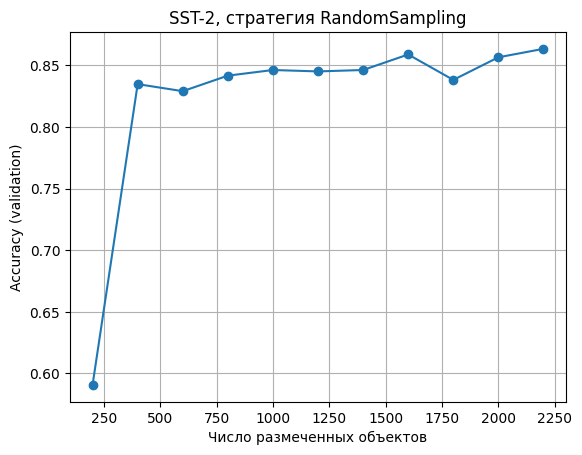

In [32]:
plt.plot(df_sst2_random["labeled"], df_sst2_random["acc"], marker="o")
plt.xlabel("Число размеченных объектов")
plt.ylabel("Accuracy (validation)")
plt.title("SST-2, стратегия RandomSampling")
plt.grid(True)
plt.show()

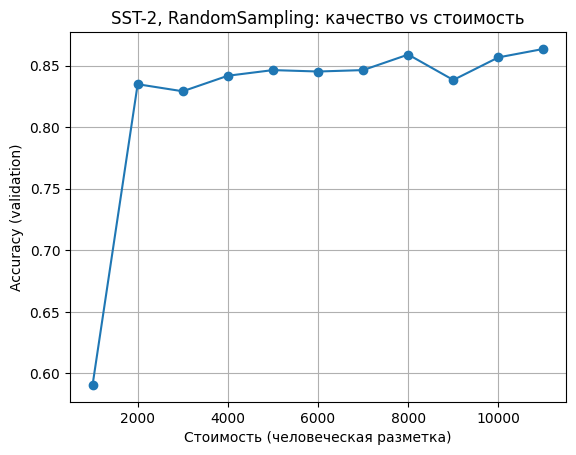

In [33]:
plt.plot(df_sst2_random["cost_human"], df_sst2_random["acc"], marker="o")
plt.xlabel("Стоимость (человеческая разметка)")
plt.ylabel("Accuracy (validation)")
plt.title("SST-2, RandomSampling: качество vs стоимость")
plt.grid(True)
plt.show()

```python
=== AL EXPERIMENT: dataset=sst2, strategy=random ===
Num classes: 2, eval split: validation
Pool size (subsampled): 10000 (original train: 67349)

 483/483 [00:00<00:00, 45.0kB/s]
tokenizer_config.json: 100%
 48.0/48.0 [00:00<00:00, 5.48kB/s]
vocab.txt: 100%
 232k/232k [00:00<00:00, 1.42MB/s]
tokenizer.json: 100%
 466k/466k [00:00<00:00, 5.56MB/s]
model.safetensors: 100%
 268M/268M [00:01<00:00, 226MB/s]
Initial labeled: 200
[Iter 00] labeled= 200 | acc=0.6388 | macro_f1=0.6032 | cost_human=1000.0
[Iter 01] labeled= 400 | acc=0.7420 | macro_f1=0.7329 | cost_human=2000.0
[Iter 02] labeled= 600 | acc=0.8326 | macro_f1=0.8324 | cost_human=3000.0
[Iter 03] labeled= 800 | acc=0.8303 | macro_f1=0.8298 | cost_human=4000.0
[Iter 04] labeled=1000 | acc=0.8394 | macro_f1=0.8394 | cost_human=5000.0
[Iter 05] labeled=1200 | acc=0.8452 | macro_f1=0.8452 | cost_human=6000.0
[Iter 06] labeled=1400 | acc=0.8417 | macro_f1=0.8414 | cost_human=7000.0
[Iter 07] labeled=1600 | acc=0.8544 | macro_f1=0.8543 | cost_human=8000.0
[Iter 08] labeled=1800 | acc=0.8589 | macro_f1=0.8588 | cost_human=9000.0
[Iter 09] labeled=2000 | acc=0.8601 | macro_f1=0.8595 | cost_human=10000.0
[Iter 10] labeled=2200 | acc=0.8624 | macro_f1=0.8624 | cost_human=11000.0
```

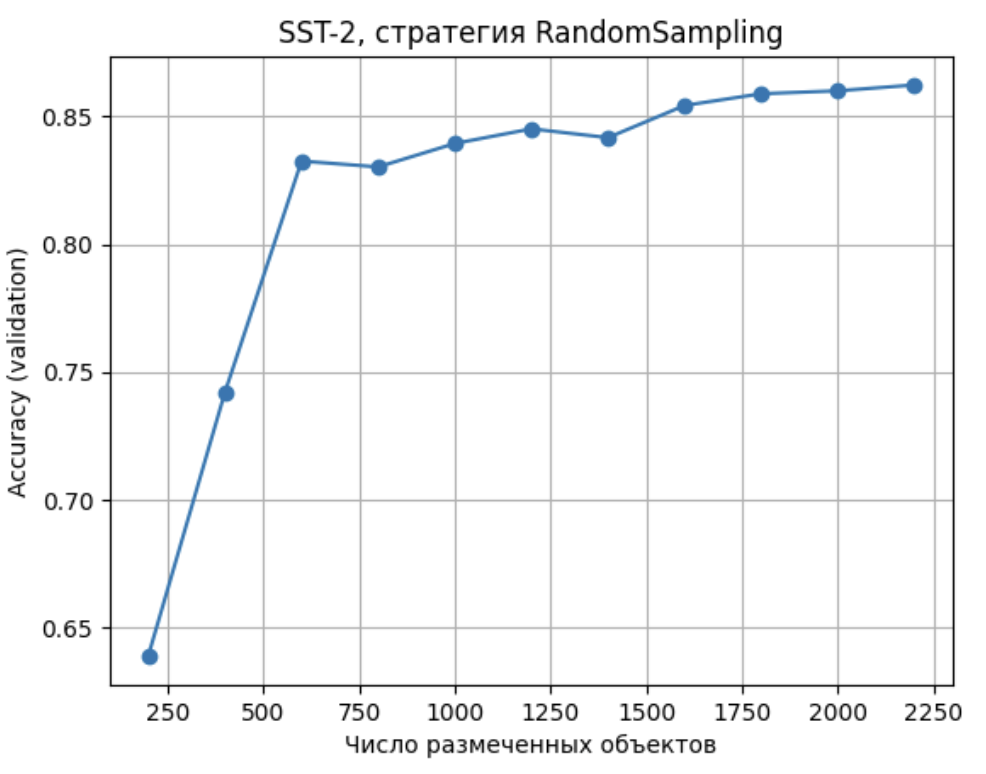


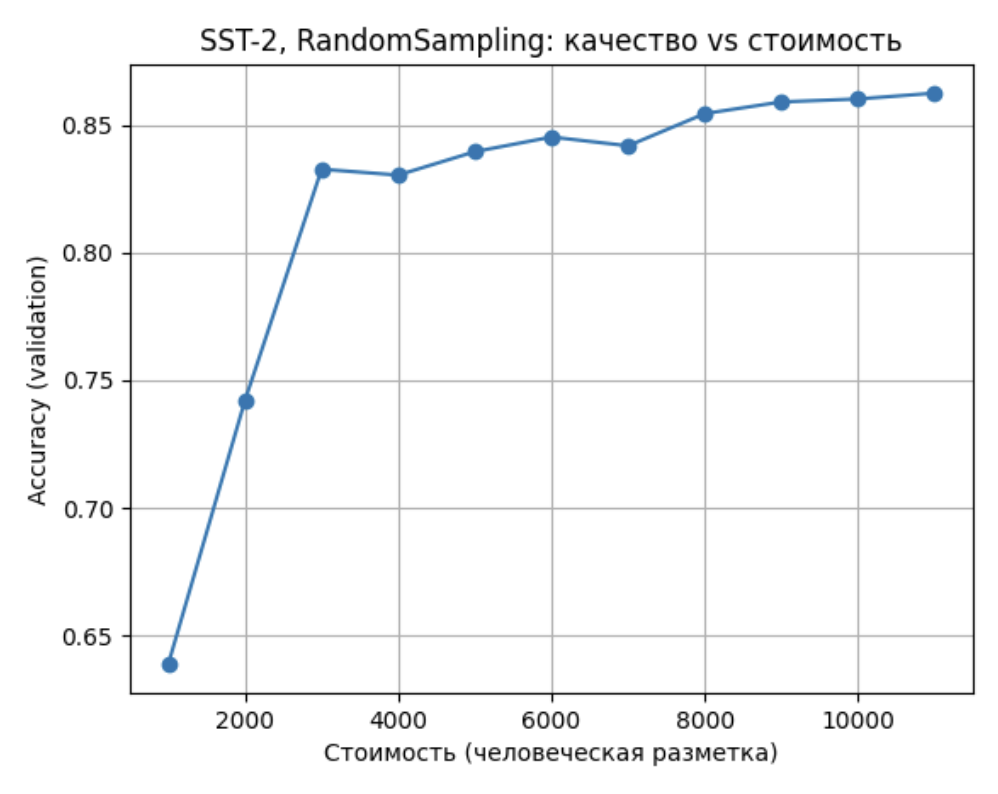

In [34]:
history_sst2_lc = run_al_experiment_one(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="least_conf",
    cfg=AL_CFG,
    experiment_name="lc"
)



=== AL EXPERIMENT: dataset=sst2, strategy=least_conf ===
Num classes: 2, eval split: validation
Pool size (subsampled): 10000 (original train: 67349)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Initial labeled: 200
[Iter 00] labeled= 200 | acc=0.7580 | macro_f1=0.7558 | cost_human=1000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/lc/iter_00
[Iter 01] labeled= 400 | acc=0.8211 | macro_f1=0.8211 | cost_human=2000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/lc/iter_01
[Iter 02] labeled= 600 | acc=0.8326 | macro_f1=0.8324 | cost_human=3000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/lc/iter_02
[Iter 03] labeled= 800 | acc=0.8475 | macro_f1=0.8475 | cost_human=4000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/lc/iter_03
[Iter 04] labeled=1000 | acc=0.8440 | macro_f1=0.8440 | cost_human=5000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/lc/iter_04
[Iter 05] labeled=1200 | acc=0.8337 | macro_f1=0.8336 | cost_human=6000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/lc/ite

In [36]:
# history_sst2_lc = pd.DataFrame(history_sst2_random)
# history_sst2_lc
df_lc = pd.read_csv("/content/drive/MyDrive/al_two_oracles/logs/lc_history.csv")


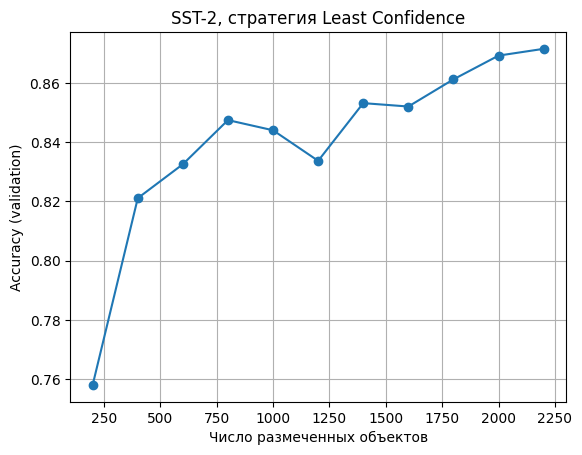

In [37]:
plt.plot(df_lc["labeled"], df_lc["acc"], marker="o")
plt.xlabel("Число размеченных объектов")
plt.ylabel("Accuracy (validation)")
plt.title("SST-2, стратегия Least Confidence")
plt.grid(True)
plt.show()

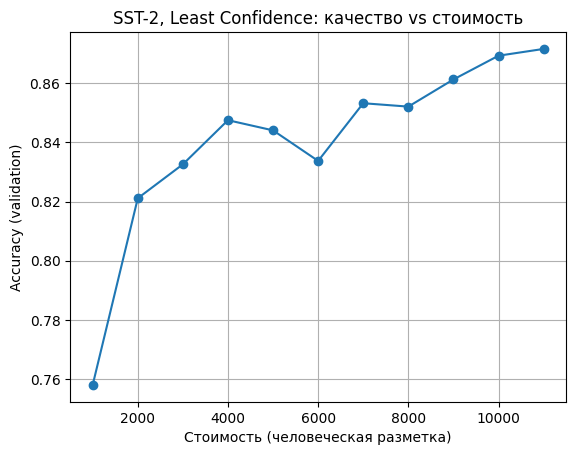

In [38]:
plt.plot(df_lc["cost_human"], df_lc["acc"], marker="o")
plt.xlabel("Стоимость (человеческая разметка)")
plt.ylabel("Accuracy (validation)")
plt.title("SST-2, Least Confidence: качество vs стоимость")
plt.grid(True)
plt.show()

In [39]:
history_sst2_bald = run_al_experiment_one(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="bald",
    cfg=AL_CFG,
    experiment_name="sst2_bald",
)


=== AL EXPERIMENT: dataset=sst2, strategy=bald ===
Num classes: 2, eval split: validation
Pool size (subsampled): 10000 (original train: 67349)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Initial labeled: 200
[Iter 00] labeled= 200 | acc=0.4966 | macro_f1=0.3416 | cost_human=1000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_bald/iter_00


/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1024: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


[Iter 01] labeled= 400 | acc=0.8222 | macro_f1=0.8221 | cost_human=2000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_bald/iter_01


...

[Iter 08] labeled=1800 | acc=0.8647 | macro_f1=0.8646 | cost_human=9000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_bald/iter_08


/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1024: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


[Iter 09] labeled=2000 | acc=0.8761 | macro_f1=0.8761 | cost_human=10000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_bald/iter_09


/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1024: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


[Iter 10] labeled=2200 | acc=0.8647 | macro_f1=0.8645 | cost_human=11000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_bald/iter_10
History saved to:
  /content/drive/MyDrive/al_two_oracles/logs/sst2_bald_history.json
  /content/drive/MyDrive/al_two_oracles/logs/sst2_bald_history.csv


In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# history_sst2_bald = pd.DataFrame(history_sst2_bald)
# print(history_sst2_bald)
df_bald = pd.read_csv("/content/drive/MyDrive/al_two_oracles/logs/sst2_bald_history.csv")


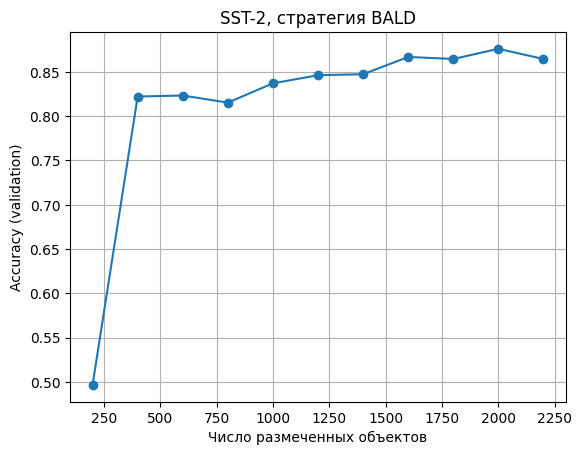

In [41]:
plt.plot(df_bald["labeled"], df_bald["acc"], marker="o")
plt.xlabel("Число размеченных объектов")
plt.ylabel("Accuracy (validation)")
plt.title("SST-2, стратегия BALD")
plt.grid(True)
plt.show()

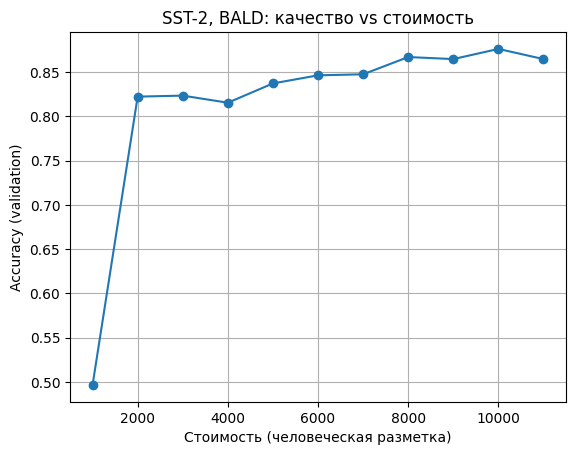

In [42]:
plt.plot(df_bald["cost_human"], df_bald["acc"], marker="o")
plt.xlabel("Стоимость (человеческая разметка)")
plt.ylabel("Accuracy (validation)")
plt.title("SST-2, BALD: качество vs стоимость")
plt.grid(True)
plt.show()

In [44]:
history_sst2_badge = run_al_experiment_one(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="badge",
    cfg=AL_CFG,
    experiment_name="sst2_badge",
)


=== AL EXPERIMENT: dataset=sst2, strategy=badge ===
Num classes: 2, eval split: validation
Pool size (subsampled): 10000 (original train: 67349)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Initial labeled: 200
[Iter 00] labeled= 200 | acc=0.5413 | macro_f1=0.4309 | cost_human=1000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_badge/iter_00


  0%|          | 0/10000 [00:00<?, ?it/s]


TypeError: DistilBertForSequenceClassification.forward() got an unexpected keyword argument 'token_type_ids'

In [ ]:
df_badge = pd.read_csv("/content/drive/MyDrive/al_two_oracles/logs/sst2_badge_history.csv")

plt.plot(df_badge["labeled"], df_badge["acc"], marker="o")
plt.xlabel("Число размеченных объектов")
plt.ylabel("Accuracy (validation)")
plt.title("SST-2, стратегия BADGE")
plt.grid(True)
plt.show()

plt.plot(df_badge["cost_human"], df_badge["acc"], marker="o")
plt.xlabel("Стоимость (человеческая разметка)")
plt.ylabel("Accuracy (validation)")
plt.title("SST-2, BADGE: качество vs стоимость")
plt.grid(True)
plt.show()

In [ ]:
def summarize_cold_start(history, points=(200, 400, 600, 800, 2200)):
    """
    history: список словарей из run_al_experiment_one.
    points: интересующие значения labeled.
    Возвращает словарь: {labeled: (acc, macro_f1)}.
    """
    df = pd.DataFrame(history)
    result = {}
    for n in points:
        row = df[df["labeled"] == n]
        if not row.empty:
            r = row.iloc[0]
            result[int(n)] = dict(acc=float(r["acc"]), macro_f1=float(r["macro_f1"]))
        else:
            result[int(n)] = None
    return result


In [ ]:
summary_rand = summarize_cold_start(history_sst2_random)
summary_lc = summarize_cold_start(history_sst2_lc)
summary_bald = summarize_cold_start(history_sst2_bald)
summary_badge = summarize_cold_start(history_sst2_badge)

summary_rand, summary_lc, summary_bald, summary_badge